**Customer segmentation and churn prediction**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("Telco_customer_churn (1).xlsx")

In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


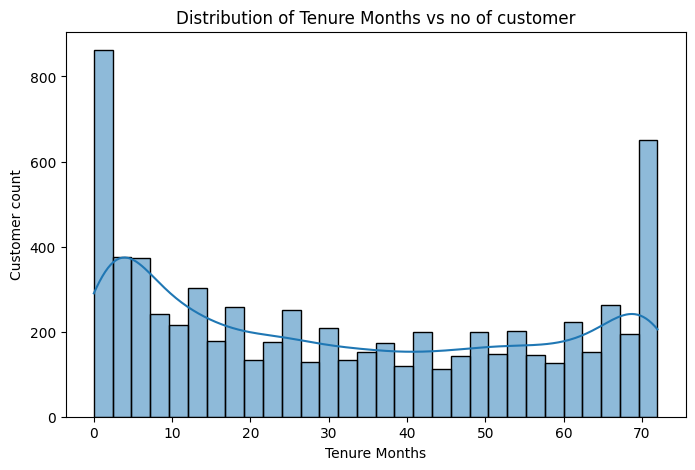

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

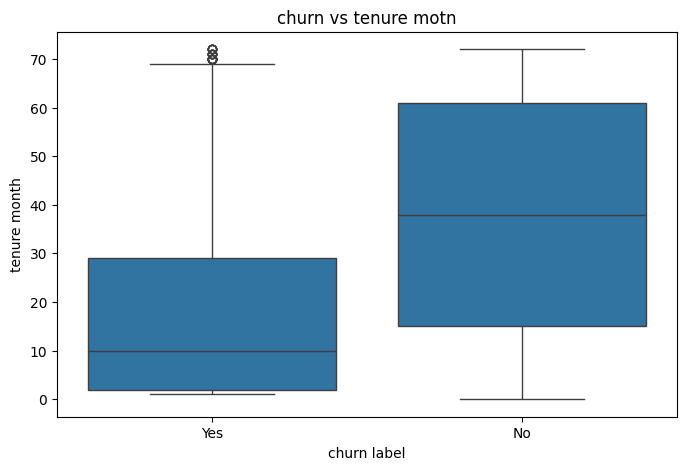

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [8]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
df [df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


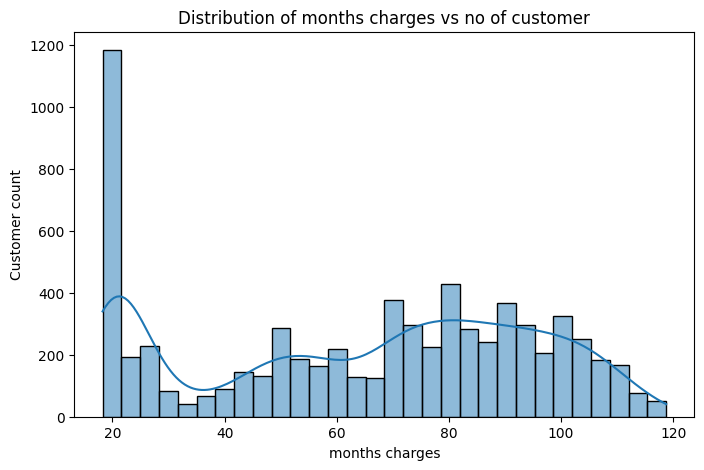

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [11]:
df['Monthly Charges'].max()

118.75

In [12]:
df['Monthly Charges'].min()

18.25

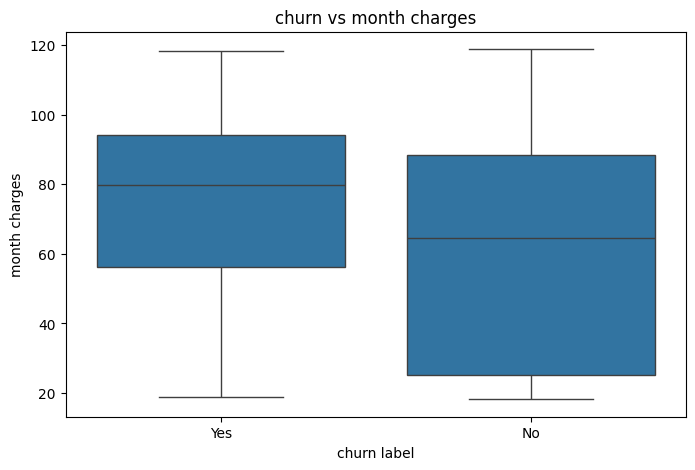

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('month charges')
plt.title('churn vs month charges')
plt.show()

In [14]:
df [df['Churn Label']=='Yes'] ['Monthly Charges'].quantile ([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [15]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [16]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [17]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

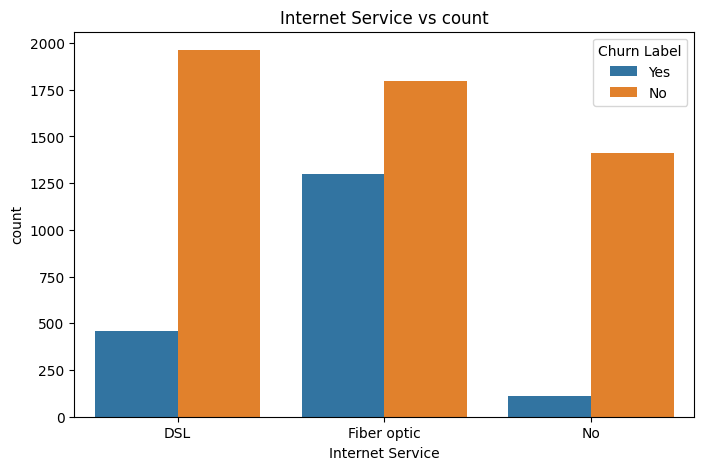

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [19]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

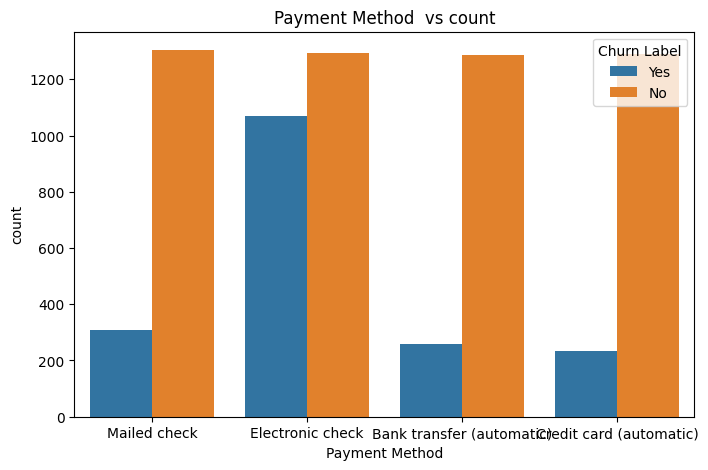

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method  vs count')
plt.show()

In [21]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [22]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [23]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [25]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()

In [26]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [27]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

In [28]:
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data cleaning


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [30]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [31]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [32]:
df['Total Charges'].dtype

dtype('float64')

In [33]:
df['Total Charges'].isnull().sum()


np.int64(11)

In [34]:
df[['Total Charges', 'Tenure Months']].isnull().sum()

,0
Total Charges,11
Tenure Months,0


In [35]:
# Show specific columns where 'Total Charges' is missing
df.loc[df['Total Charges'].isnull(), ['Total Charges', 'Tenure Months']]

,Total Charges,Tenure Months
2234,NaN,0
2438,NaN,0
2568,NaN,0
2667,NaN,0
2856,NaN,0
4331,NaN,0
4687,NaN,0
5104,NaN,0
5719,NaN,0
6772,NaN,0


In [36]:
df[df['Total Charges'].isnull()][['Tenure Months']]
#Returns a DataFrame showing the 'Tenure Months' values for all rows where 'Total Charges' is missing

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [37]:
# 2. Corrected drop (without StateID)
drop_columns = ['CustomerID', 'Count', 'Country', 'State', 'Zip Code']
df = df.drop(columns=drop_columns)

In [38]:
# 3. Check shape after dropping
df.shape

(7043, 28)

City Encoding


In [39]:
df['City'].unique()

df['City'].value_counts()



,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [40]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [41]:
df = df.drop(columns=['City'])

In [42]:
# 4. Get dataframe info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Lat Long           7043 non-null   object 
 1   Latitude           7043 non-null   float64
 2   Longitude          7043 non-null   float64
 3   Gender             7043 non-null   object 
 4   Senior Citizen     7043 non-null   object 
 5   Partner            7043 non-null   object 
 6   Dependents         7043 non-null   object 
 7   Tenure Months      7043 non-null   int64  
 8   Phone Service      7043 non-null   object 
 9   Multiple Lines     7043 non-null   object 
 10  Internet Service   7043 non-null   object 
 11  Online Security    7043 non-null   object 
 12  Online Backup      7043 non-null   object 
 13  Device Protection  7043 non-null   object 
 14  Tech Support       7043 non-null   object 
 15  Streaming TV       7043 non-null   object 
 16  Streaming Movies   7043 

Feature / Target Split

In [43]:
# 5. Create dummy variables for categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

In [44]:
# 6. View first few rows of encoded dataframe
df_encoded.head()

,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,"Lat Long_32.578103, -117.012975","Lat Long_32.579134, -117.119009",...,Churn Reason_Lack of self-service on Website,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction
0,33.964131,-118.272783,2,53.85,108.15,1,86,3239,False,False,...,False,False,False,False,False,False,False,False,False,False
1,34.059281,-118.307420,2,70.70,151.65,1,67,2701,False,False,...,False,False,False,True,False,False,False,False,False,False
2,34.048013,-118.293953,8,99.65,820.50,1,86,5372,False,False,...,False,False,False,True,False,False,False,False,False,False
3,34.062125,-118.315709,28,104.80,3046.05,1,84,5003,False,False,...,False,False,False,True,False,False,False,False,False,False
4,34.039224,-118.266293,49,103.70,5036.30,1,89,5340,False,False,...,False,False,False,False,False,False,False,False,False,False


In [45]:
# 8. Check shape after dropping City
df.shape

(7043, 27)

In [46]:
# 9. Check missing values in Total Charges
df['Total Charges'].isnull().sum()

np.int64(11)

In [47]:
# 10. Check data type of Total Charges
df['Total Charges'].dtype

dtype('float64')

In [48]:
# 11. Define features (X) and target (y)
x = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

In [49]:
# 12. Check shapes
x.shape
y.shape

(7043,)

In [50]:
# 13. Print features
print(x)

       Latitude   Longitude  Tenure Months  Monthly Charges  Total Charges  \
0     33.964131 -118.272783              2            53.85         108.15   
1     34.059281 -118.307420              2            70.70         151.65   
2     34.048013 -118.293953              8            99.65         820.50   
3     34.062125 -118.315709             28           104.80        3046.05   
4     34.039224 -118.266293             49           103.70        5036.30   
...         ...         ...            ...              ...            ...   
7038  34.341737 -116.539416             72            21.15        1419.40   
7039  34.667815 -117.536183             24            84.80        1990.50   
7040  34.559882 -115.637164             72           103.20        7362.90   
7041  34.167800 -116.864330             11            29.60         346.45   
7042  34.424926 -117.184503             66           105.65        6844.50   

      Churn Score  CLTV  Lat Long_32.578103, -117.012975  \
0  

In [51]:
# 14. Print target
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


Train Test Split

In [52]:
# 15. Import train_test_split
from sklearn.model_selection import train_test_split

In [53]:
# 16. Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [54]:
# 17. Check shapes of splits
X_train.shape
# (5634, 30)
X_test.shape
# (1409, 30)
y_train.shape
# (5634,)
y_test.shape
# (1409,)

(1409,)

Random Forest

In [55]:
# 18. Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [56]:
# 19. Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [57]:
# 20. Train the model
rf_model.fit(X_train, y_train)
# Output: RandomForestClassifier(random_state=42)

RandomForestClassifier(random_state=42)

In [58]:
# 21. Make predictions
y_pred = rf_model.predict(X_test)

Class Imbalance Handling

In [59]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [60]:
# 22. View actual test values
y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [61]:
# 23. View predictions
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [62]:
print(x.shape)
print(y.shape)

(7043, 1705)
(7043,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
print(X_train.shape)
print(Y_train.shape)

(5634, 1705)
(5634,)


Approach 2 :Hyperparameter Tuning

In [65]:
rf_tuned = RandomForestClassifier(
    n_estimators=350,
    max_depth=11,
    random_state=42,
    class_weight='balanced'
)


rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)

In [66]:
feature_importances = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importances.head(20))

                                                Feature  Importance
1685                                    Churn Label_Yes    0.253313
5                                           Churn Score    0.185584
2                                         Tenure Months    0.046547
1680                                  Contract_Two year    0.043730
4                                         Total Charges    0.027911
1665                       Internet Service_Fiber optic    0.027598
1661                                     Dependents_Yes    0.023986
1683                    Payment Method_Electronic check    0.022741
3                                       Monthly Charges    0.019208
1673                   Tech Support_No internet service    0.019003
1675                   Streaming TV_No internet service    0.017042
1689  Churn Reason_Competitor offered higher downloa...    0.015721
1667                Online Security_No internet service    0.015552
1686            Churn Reason_Attitude of support

In [67]:
print(rf_tuned)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)


In [68]:
rf_tuned.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)

In [69]:
y_pred_tuned = rf_tuned.predict(X_test)

In [70]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1009
           1       0.94      0.99      0.97       400

    accuracy                           0.98      1409
   macro avg       0.97      0.98      0.98      1409
weighted avg       0.98      0.98      0.98      1409



Accuracy

In [71]:
# 24. Import accuracy_score
from sklearn.metrics import accuracy_score

In [72]:
# 25. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

In [73]:
# 26. Print accuracy
print(accuracy)


0.9992902767920511


In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1009    0]
 [   1  399]]


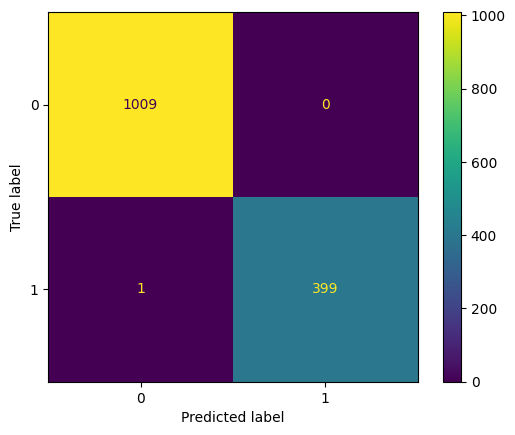

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



Feature Importance

In [77]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                                                Feature  Importance
1685                                    Churn Label_Yes    0.315755
5                                           Churn Score    0.186099
2                                         Tenure Months    0.035269
4                                         Total Charges    0.027344
1686            Churn Reason_Attitude of support person    0.023230
1689  Churn Reason_Competitor offered higher downloa...    0.020107
1690          Churn Reason_Competitor offered more data    0.018775
3                                       Monthly Charges    0.018561
1692                            Churn Reason_Don't know    0.016818
1680                                  Contract_Two year    0.016363


Cross Validation

In [78]:
from sklearn.model_selection import cross_val_score

cv_accuracy = cross_val_score(
    rf_tuned,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print(cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())

[0.98438609 0.98722498 0.98438609 0.97585227 0.98863636]
Mean Accuracy: 0.9840971594941609


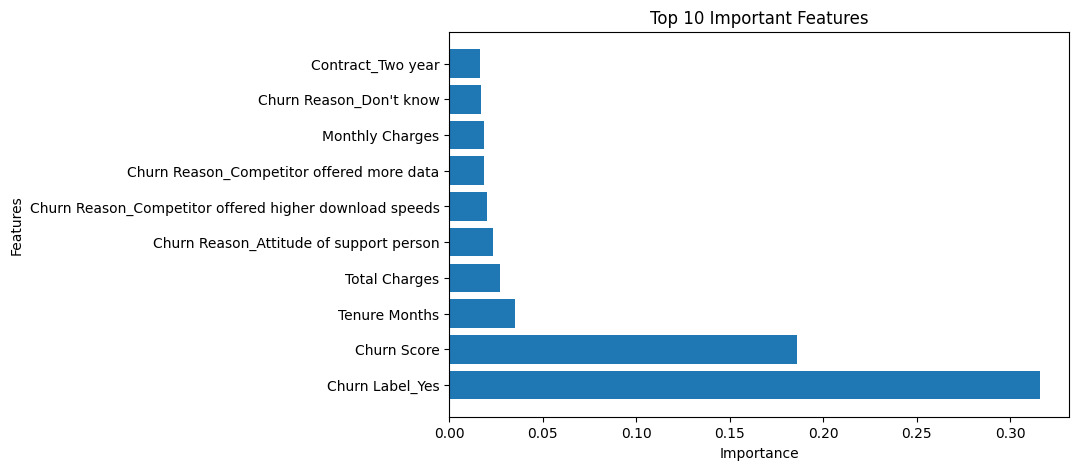

In [79]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.show()

In [80]:
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

## Customer Churn Prediction using Random Forest

This project aims to predict customer churn using machine learning techniques. Customer churn prediction helps organizations identify customers who are likely to leave the service so that retention strategies can be applied.

In [81]:
model = joblib.load("churn_model.pkl")

In [82]:
from google.colab import files
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
y_prob1 = model.predict_proba(X_test)
churn_prob = y_prob1[:,1]

## Model Evaluation

The performance of the Random Forest model is evaluated using the ROC-AUC score. A higher ROC-AUC score indicates better ability to distinguish between churned and non-churned customers.

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, churn_prob)

auc_score = roc_auc_score(y_test, churn_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 1.0


Customer Segmentation

In [85]:
seg_features = df_encoded[['Tenure Months', 'Monthly Charges', 'Total Charges']]

print(seg_features.isnull().sum())

Tenure Months       0
Monthly Charges     0
Total Charges      11
dtype: int64


In [86]:
seg_features = df_encoded[['Tenure Months', 'Monthly Charges', 'Total Charges']]

seg_features = seg_features.fillna(seg_features.mean())

In [87]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df_encoded['Segment'] = kmeans.fit_predict(seg_features)

print(df_encoded['Segment'].value_counts())

Segment
2    3243
0    1683
1    1175
3     942
Name: count, dtype: int64


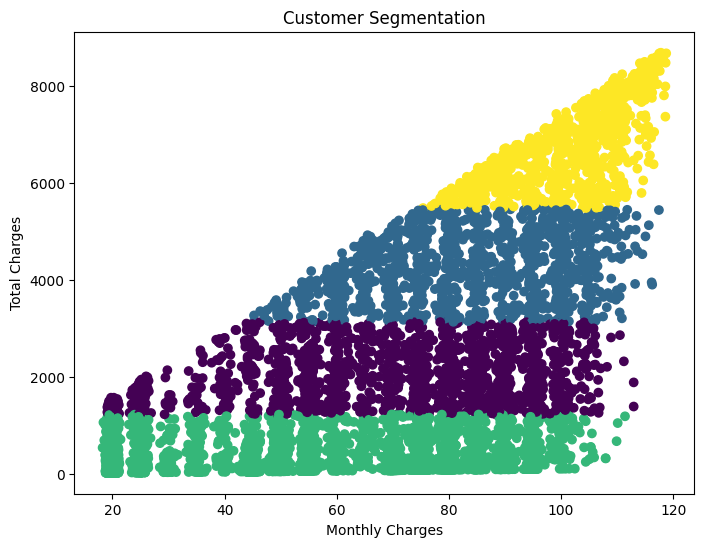

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_encoded['Monthly Charges'],
    df_encoded['Total Charges'],
    c=df_encoded['Segment']
)

plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Customer Segmentation")
plt.show()

In [89]:
df_encoded['Churn_Probability'] = model.predict_proba(x)[:,1]

print(df_encoded['Churn_Probability'].head())

0    0.97
1    0.95
2    0.97
3    0.99
4    0.96
Name: Churn_Probability, dtype: float64


In [90]:
high_risk = df_encoded[df_encoded['Churn_Probability'] > 0.8]

print("High Risk Customers:", len(high_risk))

high_risk.head()

High Risk Customers: 1803


,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,"Lat Long_32.578103, -117.012975","Lat Long_32.579134, -117.119009",...,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction,Segment,Churn_Probability
0,33.964131,-118.272783,2,53.85,108.15,1,86,3239,False,False,...,False,False,False,False,False,False,False,False,2,0.97
1,34.059281,-118.307420,2,70.70,151.65,1,67,2701,False,False,...,False,True,False,False,False,False,False,False,2,0.95
2,34.048013,-118.293953,8,99.65,820.50,1,86,5372,False,False,...,False,True,False,False,False,False,False,False,2,0.97
3,34.062125,-118.315709,28,104.80,3046.05,1,84,5003,False,False,...,False,True,False,False,False,False,False,False,0,0.99
4,34.039224,-118.266293,49,103.70,5036.30,1,89,5340,False,False,...,False,False,False,False,False,False,False,False,1,0.96


In [91]:
df_encoded.to_csv("customer_churn_segments.csv", index=False)

In [92]:
from google.colab import files

files.download("customer_churn_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

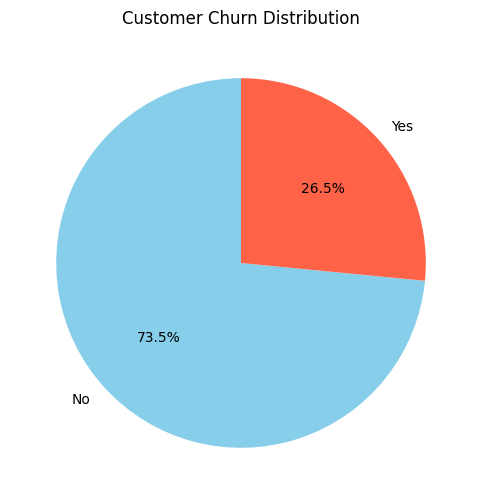

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df["Churn Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","tomato"],
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Distribution")

plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

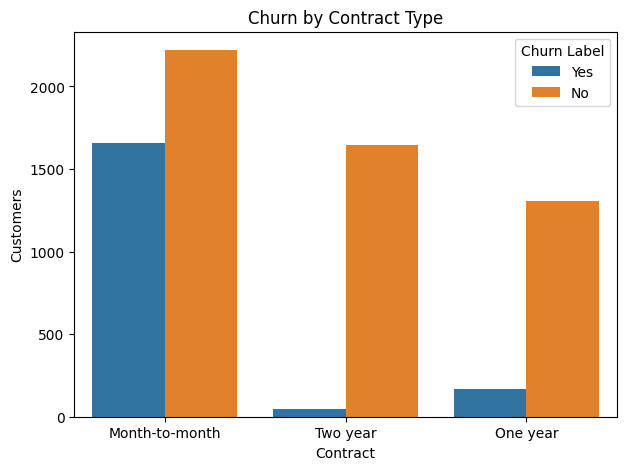

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")

plt.savefig("churn_by_contract.png", dpi=300, bbox_inches="tight")

plt.show()

In [95]:
model.feature_importances_

array([0.00983721, 0.00990279, 0.03526867, ..., 0.00949037, 0.01035676,
       0.00816297])

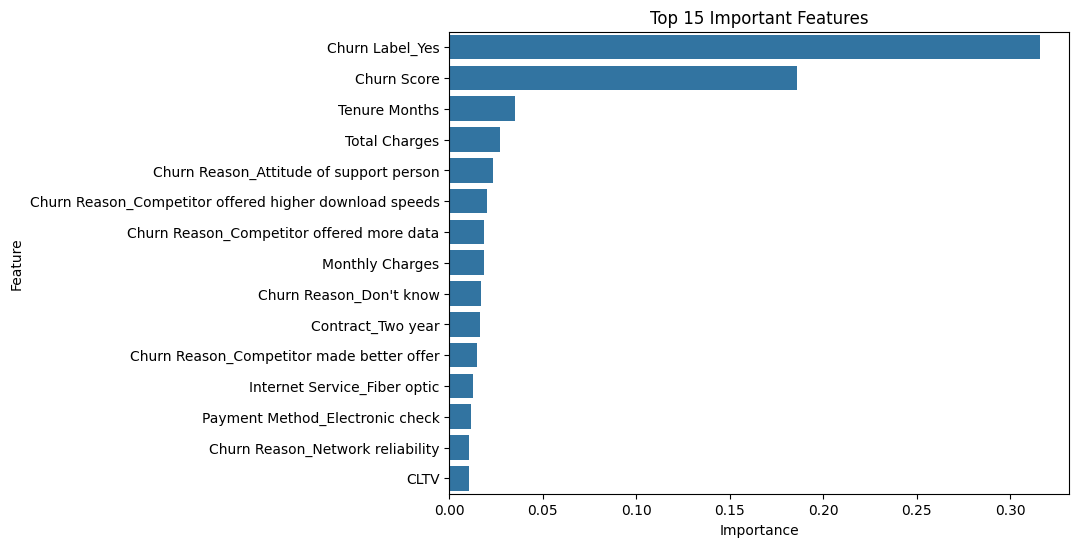

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

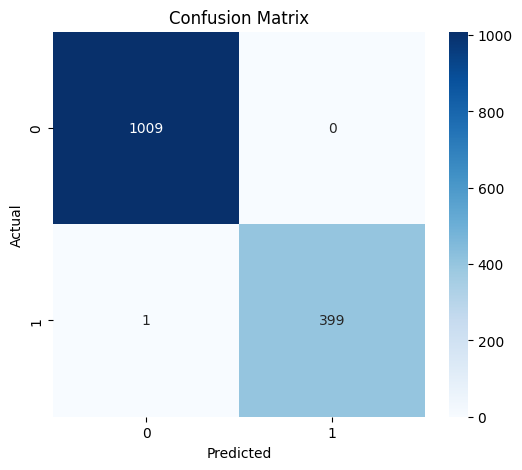

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()